In [1]:
import torch    
import json 
from ptlpinns.models import model, transfer
from ptlpinns.perturbation import LPM, standard, LKV
from ptlpinns.odes import forcing, numerical, equations
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

/home/jovyan/PTL-PINNs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load model

In [2]:
name = "underdamped_k14"

overdamped_path = f"/home/jovyan/PTL-PINNs/ptlpinns/models/train/{name}"
overdamped_name = f"model_{name}.pth"
overdamped_model, training_log = model.load_model(overdamped_path, overdamped_name)

14 True True True 1.0 16 [128, 128, 256]


In [3]:
# from ptlpinns.models.model import Multihead_model_fourier

# overdamped_model = Multihead_model_fourier(
#     k=training_log['k'],
#     bias=True,
#     use_sine=False,
#     use_fourier=False,
#     HIDDEN_LAYERS=training_log['hidden_layers'],
# )

In [4]:
# from ptlpinns.models.model import Multihead_model_fourier
# overdamped_model = Multihead_model_fourier(
#         k=training_log['k'],
#         bias=training_log['bias'],
#         use_sine=False,
#         use_fourier=False,
#         scale=training_log['scale'],
#         n_frequencies=training_log['n_frequencies'],
#         HIDDEN_LAYERS=training_log['hidden_layers'],)

### Problem definition

In [5]:
N = 512
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], N)

### Compute latent representations

In [6]:
H_dict = transfer.compute_H_dict(overdamped_model, N=N, bias=True, t_span=t_span)

### Transfer parameters

In [7]:
w_list_transfer = [1, 1]
zeta_list = [0.1, 0.2]

def forcing(numpy=False):
    if not numpy:
        def force(t):
            return torch.stack((torch.zeros_like(t), torch.zeros(t)), dim=1)
    else:
        def force(t):
            return np.stack((np.zeros_like(t), np.zeros_like(t)), axis=1)
    return force

forcing_list = [forcing(True), forcing(True), forcing(True), forcing(True), forcing(True)]

forcing_1D = lambda t: np.zeros_like(t)
ic_list = [[1, 0], [1, 0], [1, 0]]
epsilon_list = [0.1, 0.1, 0.1]
p_list = [6]
q = [(3, 1)]

### Numerical solver

In [8]:
numerical_list = []

for zeta in zeta_list:
    ode = equations.ode_oscillator_1D(w_0=w_list_transfer[0], zeta=zeta, forcing_1D=forcing_1D, q=q, epsilon=epsilon_list[0])
    numerical_list.append(numerical.solve_ode_equation(ode, (t_eval[0], t_eval[-1]), t_eval, ic_list[0]))

### PINN

In [9]:
NN_TL_solution, perturbation_solution, _ = transfer.compute_perturbation_solution(w_list_transfer, zeta_list, epsilon_list, p_list, ic_list, forcing_list, H_dict, t_eval, training_log, all_p=True, comp_time=False, solver="standard", power=q)
NN_TL_solution = NN_TL_solution.squeeze()

In [10]:
NN_TL_solution.shape

(512, 2, 2)

In [11]:
PINN_solution = []

for perturbation_zeta in perturbation_solution:

    perturbation = []
    for perturbation_order in perturbation_zeta:

        perturbation.append(perturbation_order[:, 0])

    PINN_solution.append(standard.calculate_general_series(perturbation, epsilon_list[0]))

zeta: 0.1, order: 0, mean error absolute: 0.04105040521293359
zeta: 0.1, order: 1, mean error absolute: 0.003015559587369895
zeta: 0.1, order: 2, mean error absolute: 0.00031447463447927584
zeta: 0.1, order: 3, mean error absolute: 0.000312267484916916
zeta: 0.1, order: 4, mean error absolute: 0.00031386784689471615
zeta: 0.1, order: 5, mean error absolute: 0.0003138810946049372


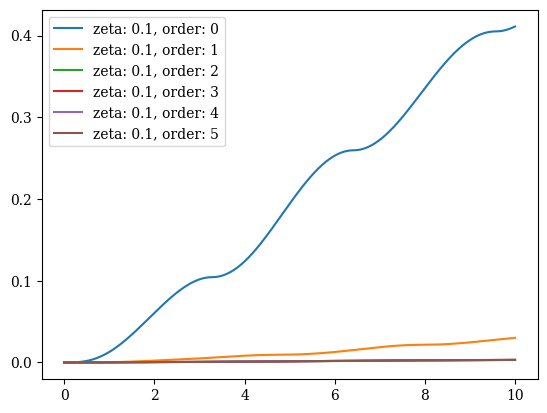

zeta: 0.2, order: 0, mean error absolute: 0.022396149124355186
zeta: 0.2, order: 1, mean error absolute: 0.0012749198789136118
zeta: 0.2, order: 2, mean error absolute: 0.0003425293771639784
zeta: 0.2, order: 3, mean error absolute: 0.00033878650772169075
zeta: 0.2, order: 4, mean error absolute: 0.00033918244702118503
zeta: 0.2, order: 5, mean error absolute: 0.00033917810761736476


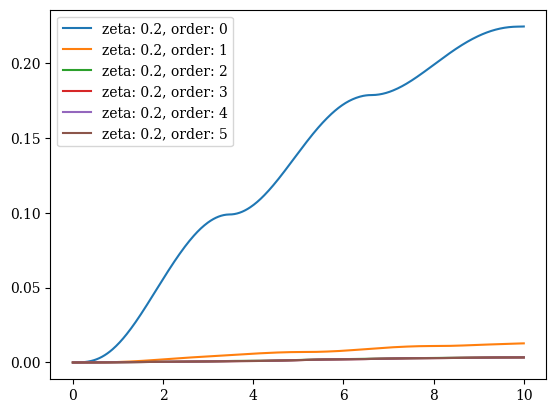

In [12]:
standard.plot_error_by_order(t_eval, PINN_solution, numerical_list, p_list, zeta_list, "zeta")

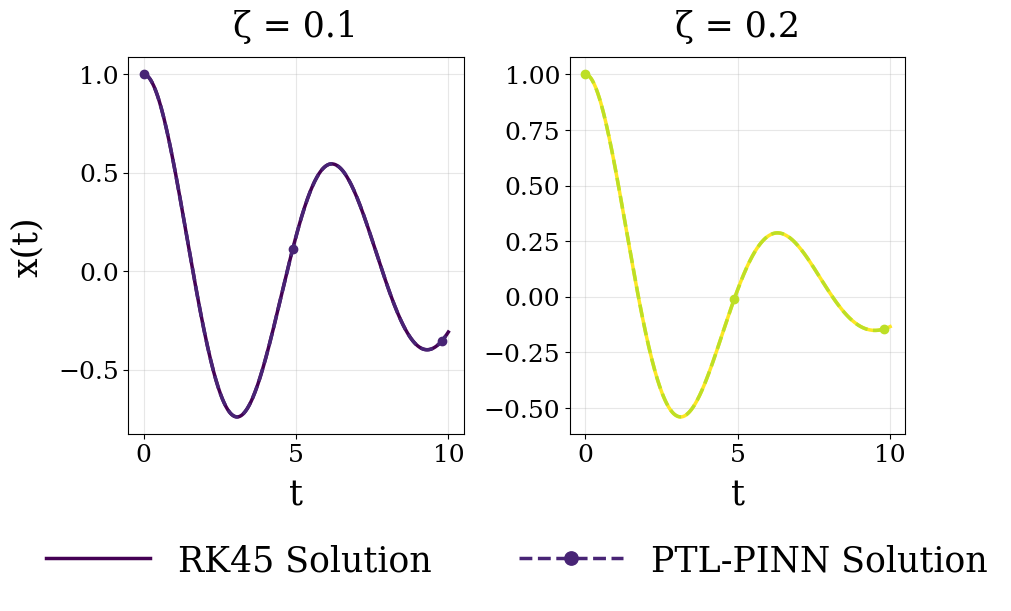

In [13]:
standard.plot_compare_multiple_zeta(t_eval, zeta_list, numerical_list, NN_TL_solution)


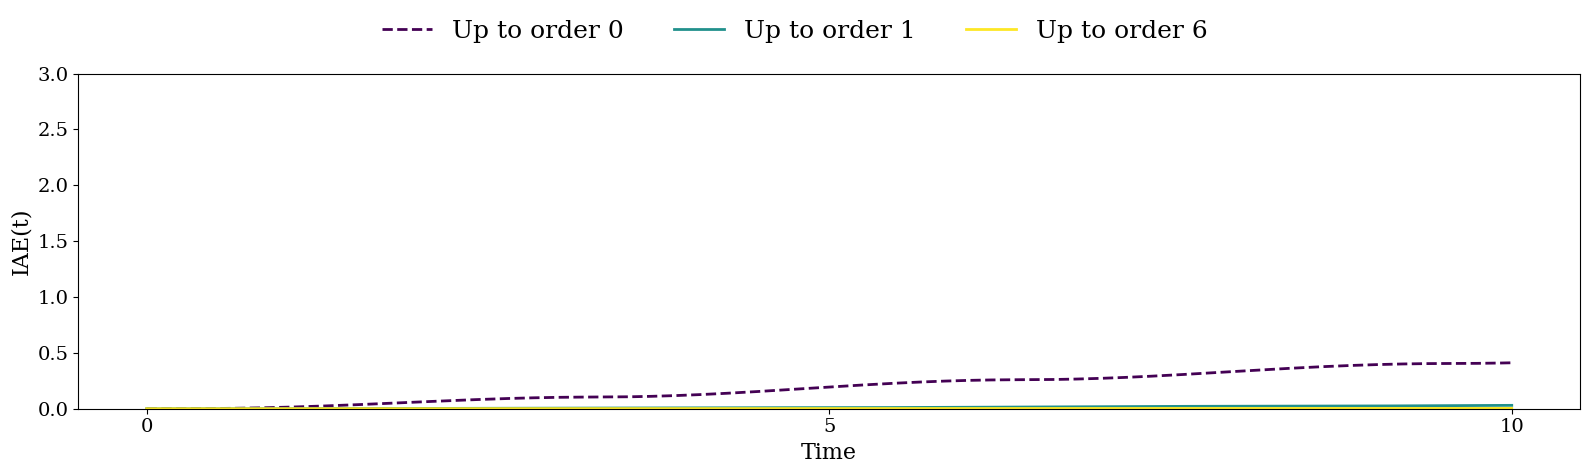

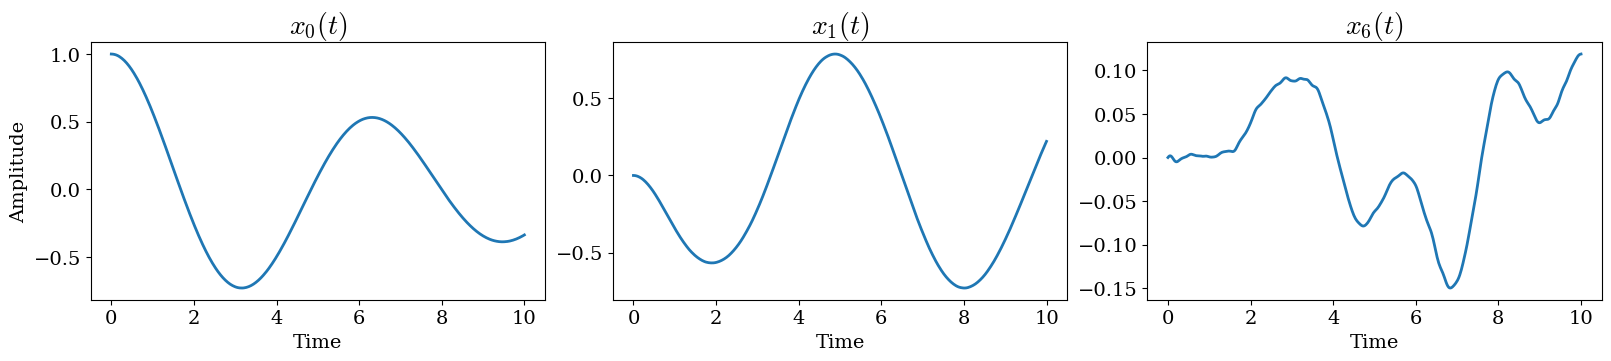

In [14]:
perturbation_solution_show = perturbation_solution[0]

PINN_x_solution = [perturbation_solution_show[i][:, 0] for i in range(len(perturbation_solution_show))]
PINN_x_solution = standard.calculate_general_series(PINN_x_solution, epsilon=epsilon_list[0])

standard.plot_IAE_and_subplots(PINN_x_solution, numerical_list[0], perturbation_solution_show, t_eval, selected_orders=[0, 1, 6], ylim=(0, 3))

/tmp/ipykernel_802815/3129563047.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", 3)


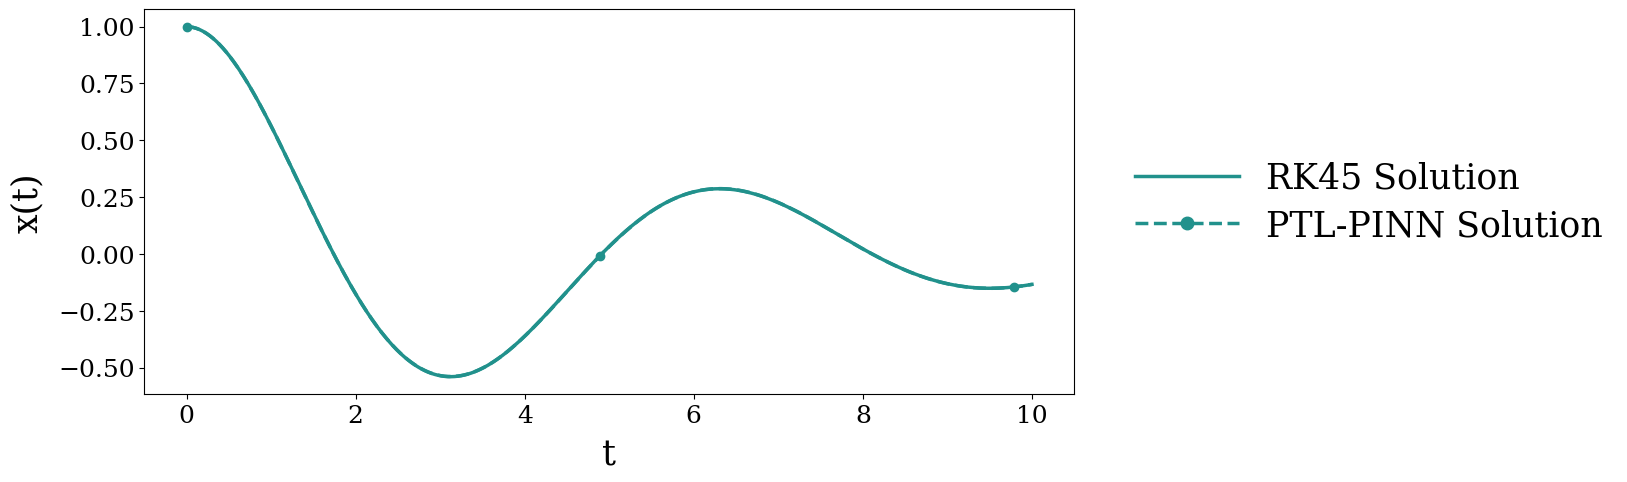

In [15]:
import matplotlib.cm as cm

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "text.usetex": False,
})

def plot_solution(t_eval, y_num, y_nn, i = 0):
    title_fs  = 25
    label_fs  = 25
    tick_fs   = 18
    legend_fs = 25
    cmap = cm.get_cmap("viridis", 3)

    fig, ax = plt.subplots(figsize=(12, 5))

    base_color = cmap(i / 2)
    rk_color   = base_color
    pinn_color = cm.viridis(0.1 + 0.8 * i / 2)

    ax.plot(t_eval, y_num,
            label="RK45 Solution",
            color=rk_color, linewidth=2.5)

    ax.plot(t_eval, y_nn,
            label="PTL-PINN Solution",
            color=pinn_color, linewidth=2.5,
            linestyle="--", marker="o", markevery=250)

    ax.set_xlabel("t", fontsize=label_fs, labelpad=8)
    ax.set_ylabel("x(t)", fontsize=label_fs, labelpad=10)

    ax.tick_params(axis='both', labelsize=tick_fs)

    # Set y-limits with padding
    y_min = min(np.min(y_num), np.min(y_nn))
    y_max = max(np.max(y_num), np.max(y_nn))
    pad = 0.05 * max(1e-12, (y_max - y_min))
    ax.set_ylim(y_min - pad, y_max + pad)

    ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  # (x, y): anchor the legend outside the right border
    fontsize=legend_fs,
    frameon=False,
    handlelength=3.0,
    markerscale=1.5,
    labelspacing=0.4,
    borderaxespad=0.8)
    plt.show()

plot_solution(t_eval, numerical_list[1][0, :], NN_TL_solution[:, 1, 0], i = 1)

In [16]:
ode_high_acc = equations.ode_oscillator_1D(w_0=1, zeta=0.5, forcing_1D=forcing_1D, q=q, epsilon=epsilon_list[0])
dt = (t_eval[1] - t_eval[0])/100
t_eval_high_acc = np.linspace(t_span[0], t_span[1], (t_eval.size - 1)*100 + 1)
num_high_acc = numerical.solve_ode_equation(ode_high_acc, (t_eval_high_acc[0], t_eval_high_acc[-1]), t_eval_high_acc, ic_list[0])[0, :]

In [17]:
error = []
for i in range(p_list[0]):
    error.append(np.mean(np.abs(PINN_solution[1][i] - num_high_acc[::100])))

In [18]:
error

[np.float64(0.1625768435522012),
 np.float64(0.17579615397225046),
 np.float64(0.17460838629823844),
 np.float64(0.17465119036398366),
 np.float64(0.17464732220654816),
 np.float64(0.17464770987488615)]

## Hyperparameter sweep — MAE vs perturbation order across underdamping regimes

The "actual model" used in this notebook is the pretrained PINN
`underdamped_k12` (sine first layer + Fourier features, multi-head).
Following the LV / overdamped sweeps, we compare it against a family of
random tanh PINNs with no Fourier features and varying hidden-layer
matrix size $W \in \{32, 64, 128, 256, 512\}$
(`Multihead_model_fourier(use_sine=False, use_fourier=False, HIDDEN_LAYERS=[W, W, 2W])`).

The sweep is repeated for three underdamping regimes
($\zeta \in \{0.25, 0.5, 0.7\}$ from the existing `zeta_list`) with the
same $\varepsilon = 0.5$, cubic nonlinearity $q = [(3, 1)]$ and forcing
$f(t) = \zeros t$ used in the standard-perturbation pipeline above.
For each $\zeta$ we plot the MAE of the cumulative position estimate
against a high-resolution Radau reference at every perturbation order
$p = 0,\dots,p_{\max}$.

In [19]:
from ptlpinns.models.model import Multihead_model_fourier


def _make_pretrained_dict():
    """Reuse the H_dict already built from the pretrained `underdamped_k12`."""
    return H_dict, training_log


def _make_tanh_dict(hidden_layers, seed=0):
    """Random tanh PINN with no Fourier features and the requested width."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    rand_model = Multihead_model_fourier(
        k=training_log["k"],
        bias=training_log["bias"],
        use_sine=False,
        use_fourier=False,
        scale=1.0,
        n_frequencies=16,
        HIDDEN_LAYERS=hidden_layers,
    )
    return transfer.compute_H_dict(rand_model, N=N, bias=True, t_span=t_span), training_log


# Compare the actual model (pretrained underdamped_k12) against the same
# tanh-no-Fourier family at several widths.
sweep_configs = [
    ("Pretrained $H$ (underdamped_k12, actual model)",
        _make_pretrained_dict),
    ("Random $H$ (tanh, no Fourier, W=32)",
        lambda: _make_tanh_dict([32,  32,  64])),
    ("Random $H$ (tanh, no Fourier, W=64)",
        lambda: _make_tanh_dict([64,  64,  128])),
    ("Random $H$ (tanh, no Fourier, W=128)",
        lambda: _make_tanh_dict([128, 128, 256])),
    ("Random $H$ (tanh, no Fourier, W=256)",
        lambda: _make_tanh_dict([256, 256, 512])),
    ("Random $H$ (tanh, no Fourier, W=512)",
        lambda: _make_tanh_dict([512, 512, 1024])),
]

# Three underdamping regimes from the existing zeta_list.
regime_zetas = list(zeta_list)   # [0.25, 0.5, 0.7]
p_max        = p_list[0]         # 6

[label for label, _ in sweep_configs], regime_zetas, p_max

(['Pretrained $H$ (underdamped_k12, actual model)',
  'Random $H$ (tanh, no Fourier, W=32)',
  'Random $H$ (tanh, no Fourier, W=64)',
  'Random $H$ (tanh, no Fourier, W=128)',
  'Random $H$ (tanh, no Fourier, W=256)',
  'Random $H$ (tanh, no Fourier, W=512)'],
 [0.1, 0.2],
 6)

In [ ]:
errors_by_regime = {}

for zeta in regime_zetas:
    ode_z = equations.ode_oscillator_1D(
        w_0=w_list_transfer[0], zeta=zeta, forcing_1D=forcing_1D,
        q=q, epsilon=epsilon_list[0],
    )

    errs_this_regime = {}
    print(f"\n=== ζ = {zeta} ===")

    for label, factory in sweep_configs:
        H_cfg, tlog = factory()
        cond_H = np.linalg.cond(H_cfg["H"])

        err = standard.compute_error_per_order_standard(
            H_dict=H_cfg,
            training_log=tlog,
            w_0=w_list_transfer[0],
            zeta=zeta,
            epsilon=epsilon_list[0],
            p_max=p_max,
            ic=ic_list[0],
            forcing_function=forcing_list[0],
            q=q,
            ode=ode_z,
            t_eval=t_eval,
        )

        legend_label = (
            f"{label}  [$\\kappa(H)$={cond_H:.1e}, "
            f"MAE@$p$={len(err) - 1}: {err[-1]:.2e}]"
        )
        errs_this_regime[legend_label] = err
        print(f"  {label:<48s}  MAE @ p={len(err) - 1}: {err[-1]:.3e}  |  cond(H)={cond_H:.2e}")

    errors_by_regime[zeta] = errs_this_regime

list(errors_by_regime.keys())


=== ζ = 0.1 ===
  Pretrained $H$ (underdamped_k12, actual model)    MAE @ p=6: 3.139e-04  |  cond(H)=5.68e+04
  Random $H$ (tanh, no Fourier, W=32)               MAE @ p=6: 2.381e-04  |  cond(H)=6.37e+05
  Random $H$ (tanh, no Fourier, W=64)               MAE @ p=6: 4.651e-04  |  cond(H)=1.01e+09
  Random $H$ (tanh, no Fourier, W=128)              MAE @ p=6: 2.491e-04  |  cond(H)=4.87e+15
  Random $H$ (tanh, no Fourier, W=256)              MAE @ p=6: 3.210e-04  |  cond(H)=2.07e+16


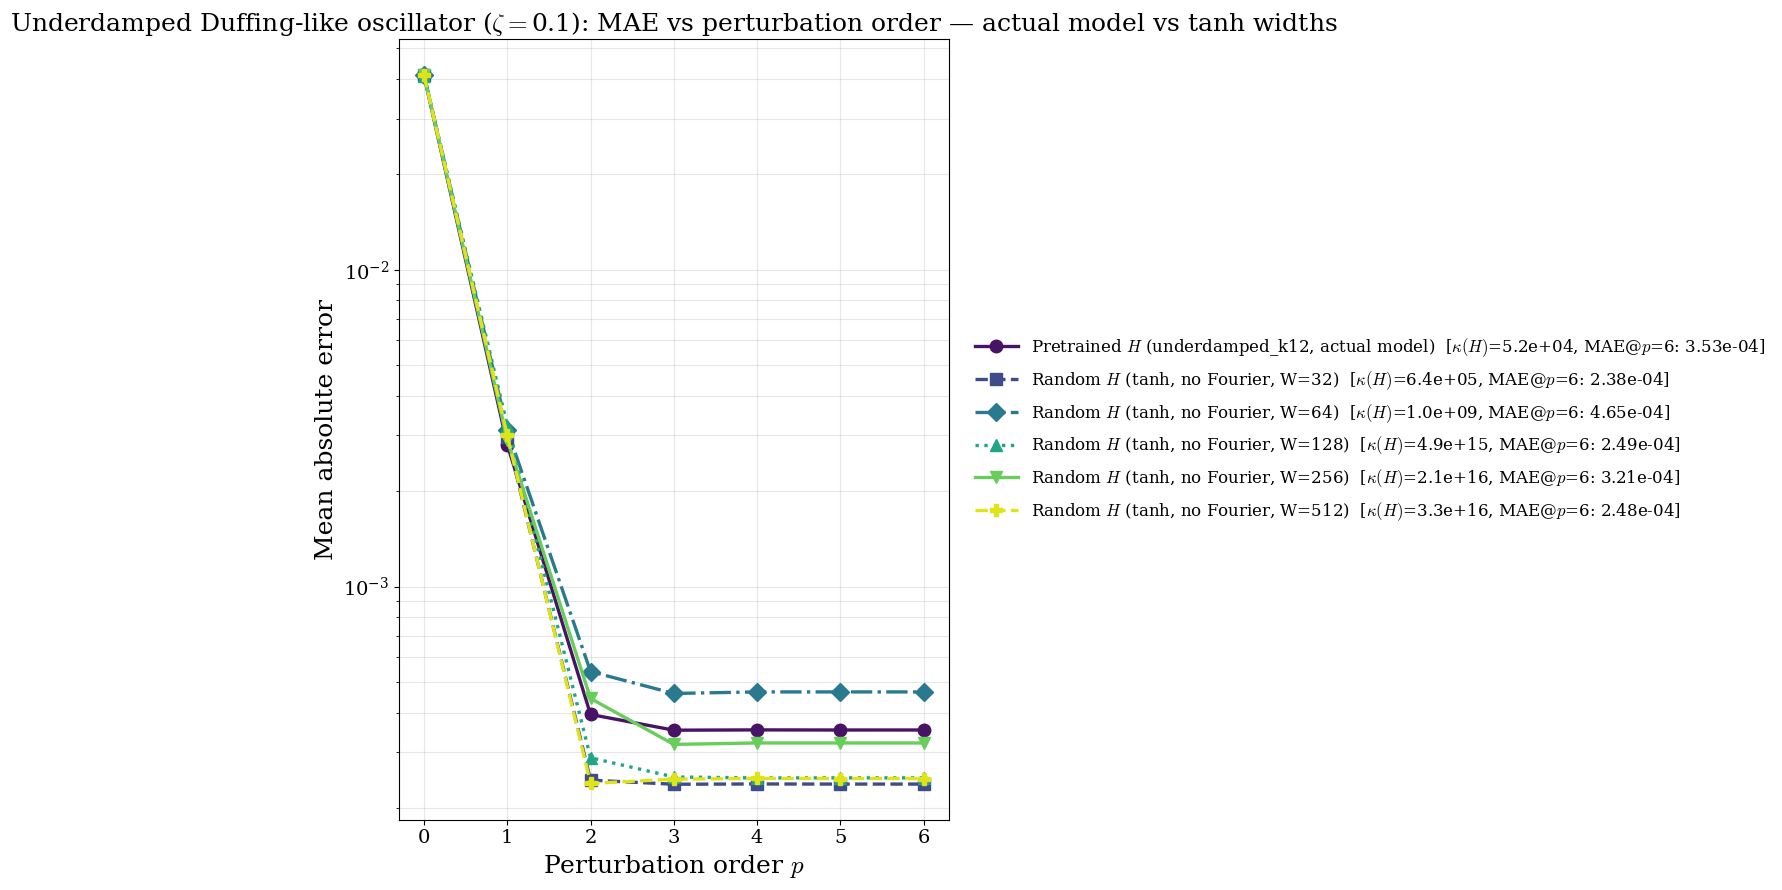

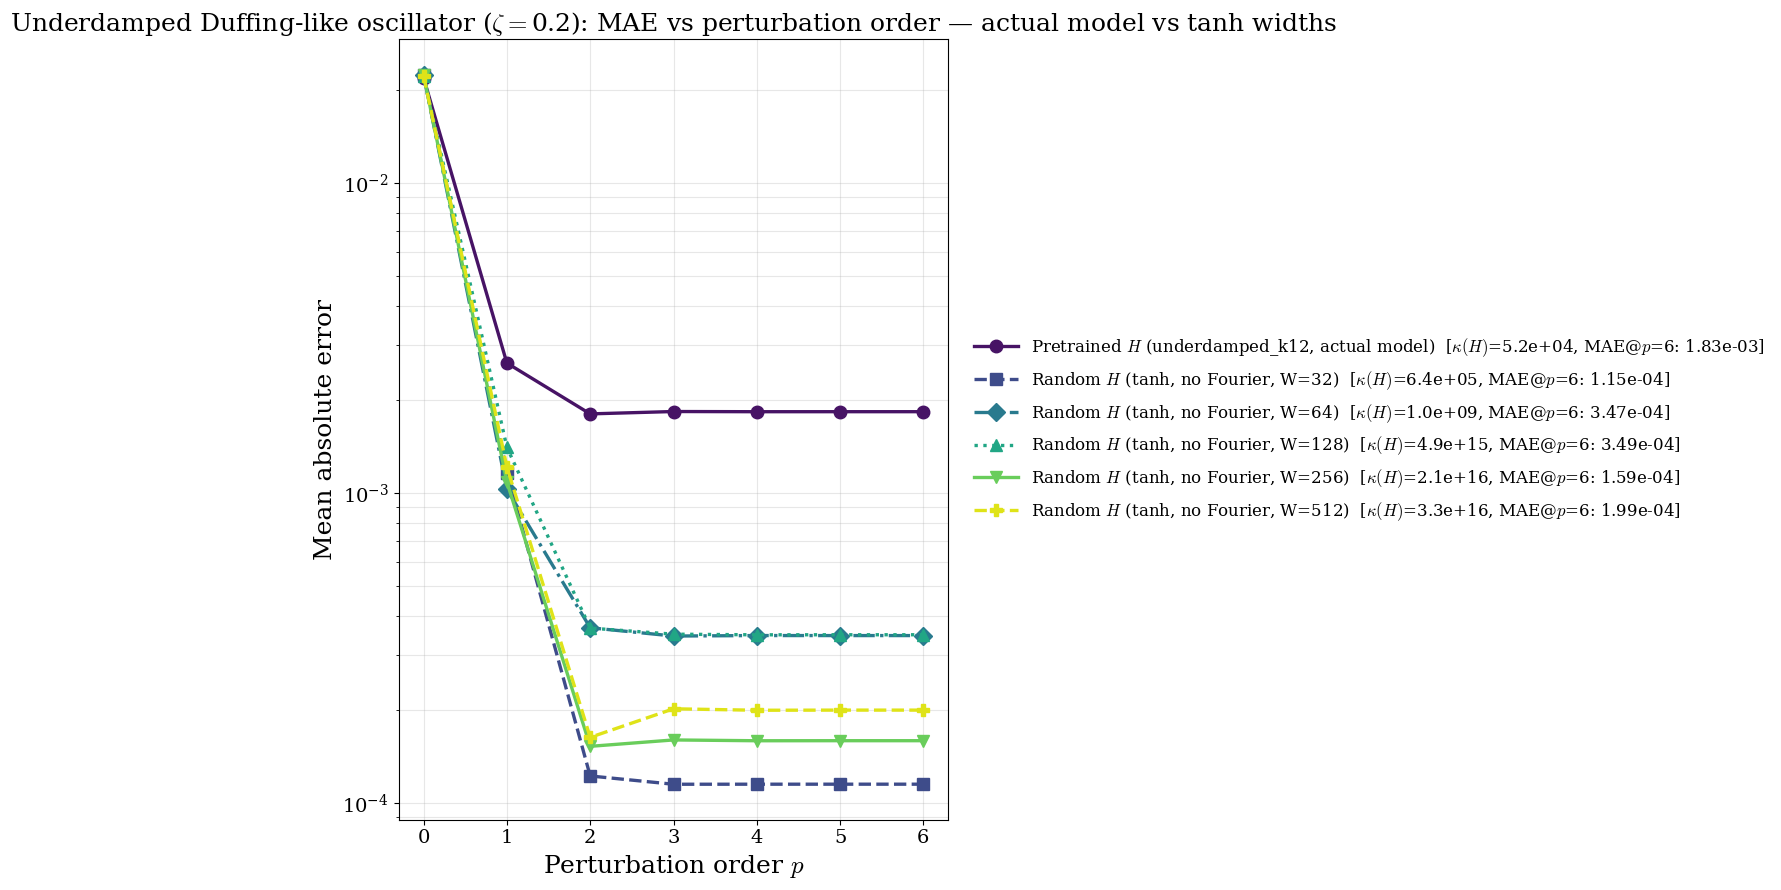

In [ ]:
for zeta, errs in errors_by_regime.items():
    LKV.plot_mae_vs_order(
        errs,
        title=(
            r"Underdamped Duffing-like oscillator ($\zeta=$" + f"{zeta}" + r"): "
            r"MAE vs perturbation order — actual model vs tanh widths"
        ),
    )

## Per-order comparison: pretrained vs random vs numerical

The same standard perturbation series for the underdamped Duffing oscillator
$\ddot x + 2\zeta\dot x + x + \varepsilon x^{3} = \zeros t,\\ x(0)=1,\\ \dot x(0)=0$\n
is computed in three ways:

1. **Pretrained PTL-PINN** — `perturbation_solution[0][i][:, 0]` from the solve above
   (using the `underdamped_k12` pretrained basis, ζ = 0.4).
2. **Random PTL-PINN** — same standard pipeline but the basis is a freshly-
   initialised tanh network with the same architecture (no training).
3. **Numerical reference** — the standard perturbation correction ODEs solved with
   `scipy.integrate.solve_ivp` on a high-accuracy grid.

The plots overlay all three for every correction order
$p = 0, 1, \dots, p_{\max}$.

In [ ]:
from ptlpinns.models.model import Multihead_model_fourier
import torch

# Build a random tanh PINN with the same architecture as underdamped_k12
# but no Fourier features and no training (random weights).
torch.manual_seed(0)
k_rand  = training_log['k']
bias_rand = training_log['bias']
rand_model = Multihead_model_fourier(
    k=k_rand,
    bias=bias_rand,
    use_sine=False,
    use_fourier=False,
    HIDDEN_LAYERS=training_log['hidden_layers'],
)
H_dict_random = transfer.compute_H_dict(rand_model, N=N, bias=True, t_span=t_span)

# Run the standard perturbation pipeline on the random basis.
_, perturbation_solution_random, _ = transfer.compute_perturbation_solution(
    w_list_transfer, zeta_list, epsilon_list, p_list, ic_list,
    forcing_list, H_dict_random, t_eval, training_log,
    all_p=True, comp_time=False, solver='standard', power=q,
)

len(perturbation_solution_random)


2

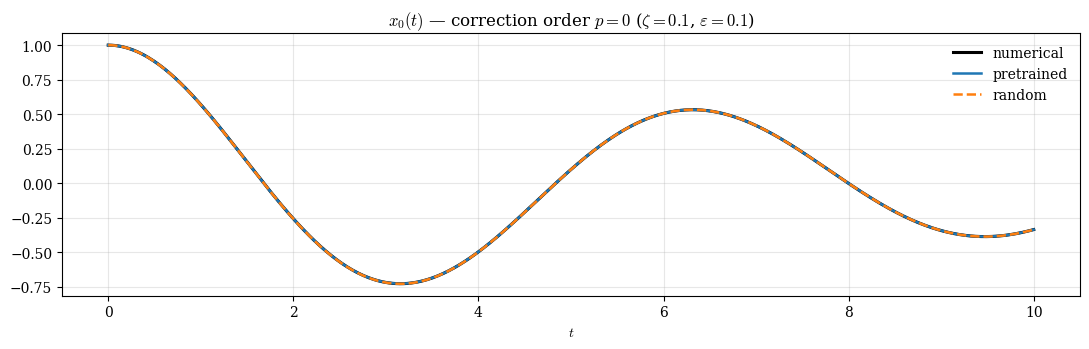

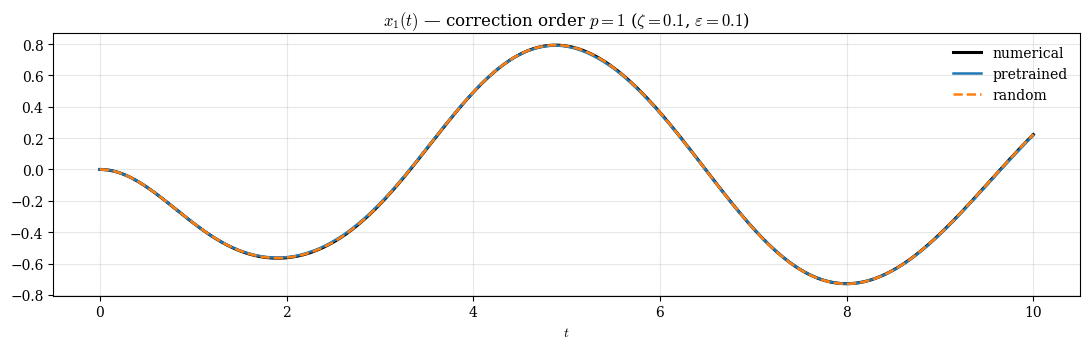

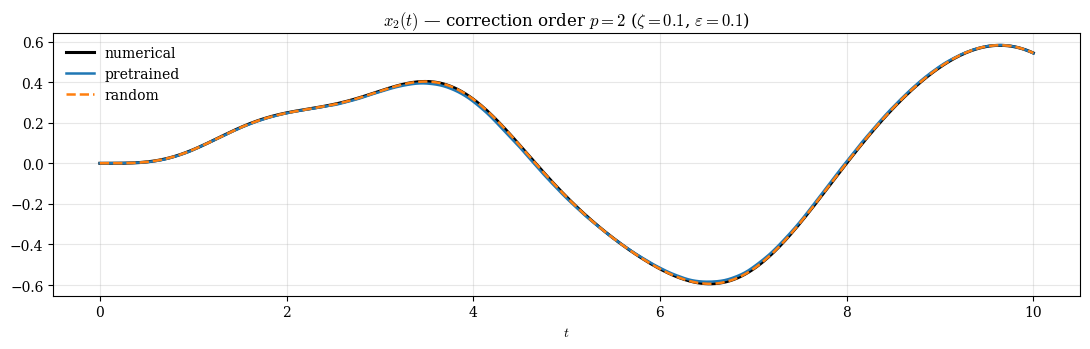

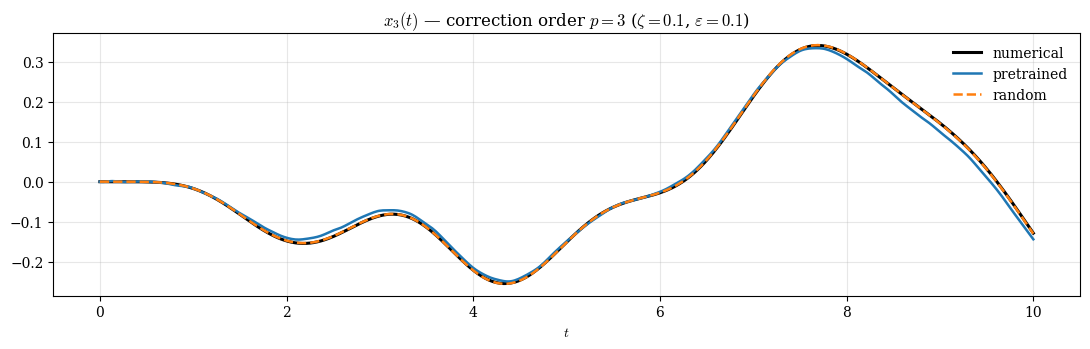

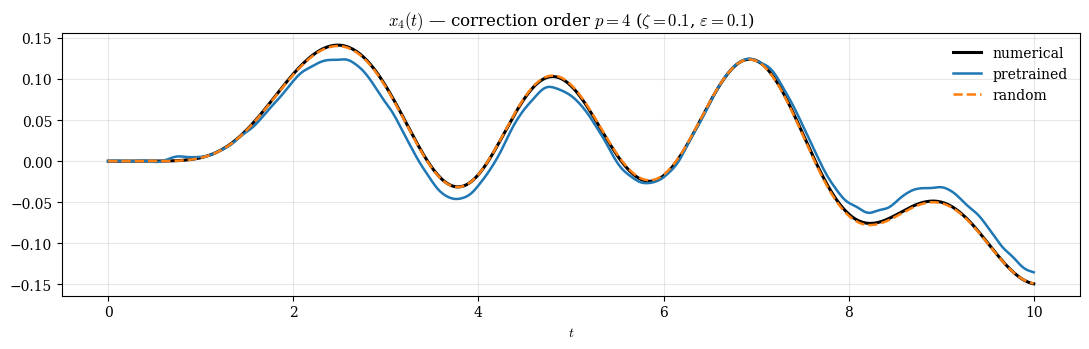

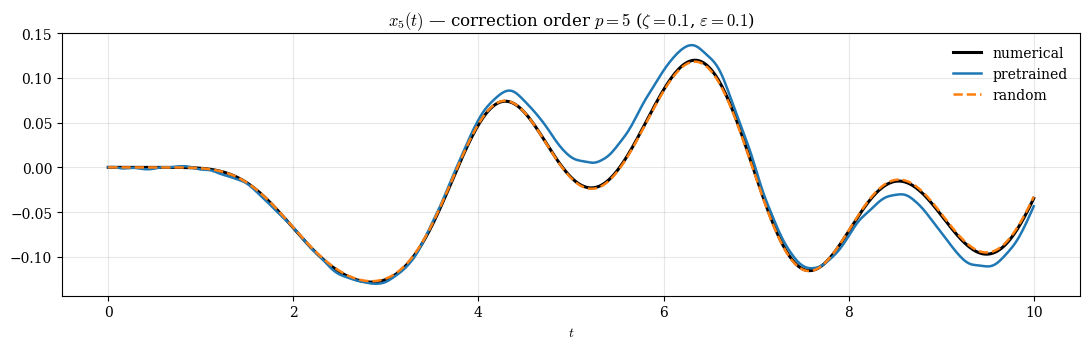

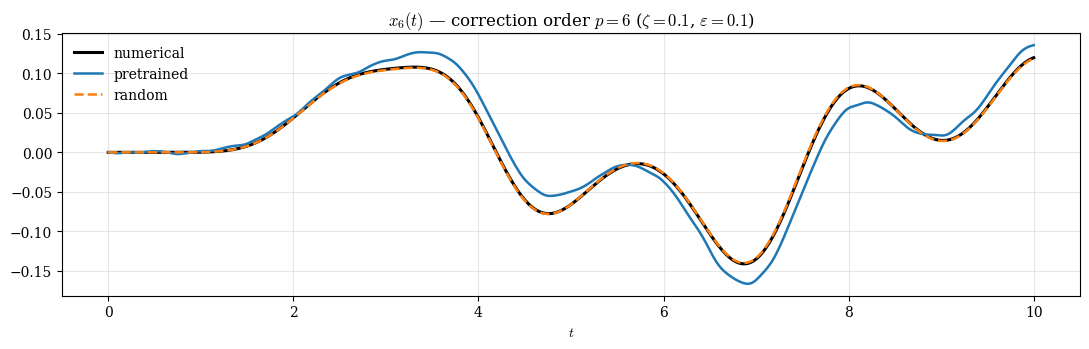

In [ ]:
from scipy.interpolate import CubicSpline

# We show the comparison for the first entry in zeta_list (ζ = 0.4).
zeta_idx  = 0
zeta_show = zeta_list[zeta_idx]

w_0_ref     = w_list_transfer[0]
epsilon_ref = epsilon_list[0]
N_hi        = 51200
t_eval_hi   = np.linspace(t_span[0], t_span[1], N_hi)

# ── Numerical reference for each correction order ────────────────────────
# Order 0: solve the *linear* ODE with the physical forcing.
ode_0_hi = equations.ode_oscillator_1D(
    w_0=w_0_ref, zeta=zeta_show,
    forcing_1D=forcing_1D,
    q=q, epsilon=0,
)
sol_0_hi = numerical.solve_ode_equation(ode_0_hi, t_span, t_eval_hi, ic_list[0])

# Build reference list in the format expected by standard.calculate_forcing:
# each entry shape (N_hi, 2) with columns [x_n, ẋ_n].
ref_list_hi = [np.stack([sol_0_hi[0, :], sol_0_hi[1, :]], axis=1)]

p_max_show = p_list[0]

for n in range(1, p_max_show + 1):
    forcing_n_hi = standard.calculate_forcing(n, q, ref_list_hi)
    forcing_n_interp = CubicSpline(t_eval_hi, forcing_n_hi)

    def _ode_xn(t, y, _w0=w_0_ref, _zeta=zeta_show, _force=forcing_n_interp):
        return np.array([y[1], -(_w0 ** 2) * y[0] - 2 * _w0 * _zeta * y[1] + _force(t)])

    sol_n_hi = numerical.solve_ode_equation(
        _ode_xn, t_span, t_eval_hi, [0.0, 0.0],
    )
    ref_list_hi.append(np.stack([sol_n_hi[0, :], sol_n_hi[1, :]], axis=1))

# Resample each correction to the coarse PTL-PINN grid.
x_num_list = [CubicSpline(t_eval_hi, e[:, 0])(t_eval) for e in ref_list_hi]

# ── Per-order overlay plots ───────────────────────────────────────────────
ps = perturbation_solution[zeta_idx]
ps_r = perturbation_solution_random[zeta_idx]

for i in range(len(ps)):
    fig, ax = plt.subplots(figsize=(11, 3.6))
    ax.plot(t_eval, x_num_list[i], 'k-', linewidth=2.2, label='numerical')
    ax.plot(t_eval, ps[i][:, 0],   linewidth=1.8, label='pretrained')
    ax.plot(t_eval, ps_r[i][:, 0], linewidth=1.8, linestyle='--', label='random')
    ax.set_title(
        rf"$x_{{{i}}}(t)$ — correction order $p = {i}$"
        rf" ($\zeta = {zeta_show}$, $\varepsilon = {epsilon_ref}$)"
    )
    ax.set_xlabel(r"$t$")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.show()
